In [1]:
import pandas as pd


In [ ]:
cudaq_all = pd.read_csv("../evaluation/data/cudaq_alltime.csv")
cudaq_q = pd.read_csv("../evaluation/data/cudaq_qtime.csv")
qiskit_all = pd.read_csv("../evaluation/data/qiskit_alltime.csv")
qiskit_q = pd.read_csv("../evaluation/data/qiskit_qtime.csv")


In [ ]:
cudaq_all = cudaq_all[["step", "all_time_value"]]
cudaq_q = cudaq_q[["step", "q_time_value"]]
qiskit_all = qiskit_all[["step", "all_time_value"]]
qiskit_q = qiskit_q[["step", "q_time_value"]]


In [5]:
cudaq_time = pd.merge(cudaq_all, cudaq_q, on='step', how='inner')
qiskit_time = pd.merge(qiskit_all, qiskit_q, on='step', how='inner')



In [6]:
def calc_avg(df):
    # Calculate mean values for every 100 steps
    step_ranges = list(range(0, df['step'].max() + 100, 100))
    avg_data = []

    _name = 3
    for i in range(len(step_ranges) - 1):
        start_step = step_ranges[i]
        end_step = step_ranges[i+1] - 1
        
        # Filter data for the current range
        range_data = df[(df['step'] >= start_step) & (df['step'] <= end_step)]
        
        if not range_data.empty:
            avg_all_time = range_data['all_time_value'].mean()
            avg_q_time = range_data['q_time_value'].mean()
            
            avg_data.append({
                'size': f'{_name}',
                'avg_all_time': avg_all_time,
                'avg_q_time': avg_q_time,
                'overhead': avg_all_time - avg_q_time,
                'overhead_percent': (avg_all_time - avg_q_time) / avg_all_time * 100
            })
        _name += 1

    # Create a DataFrame from the averaged data
    df_avg_time = pd.DataFrame(avg_data)
    return df_avg_time


In [7]:
cudaq_avg_time = calc_avg(cudaq_time)
qiskit_avg_time = calc_avg(qiskit_time)


In [8]:
cudaq_avg_time = cudaq_avg_time[cudaq_avg_time['size'].astype(int) < 12]
qiskit_avg_time = qiskit_avg_time[qiskit_avg_time['size'].astype(int) < 12]


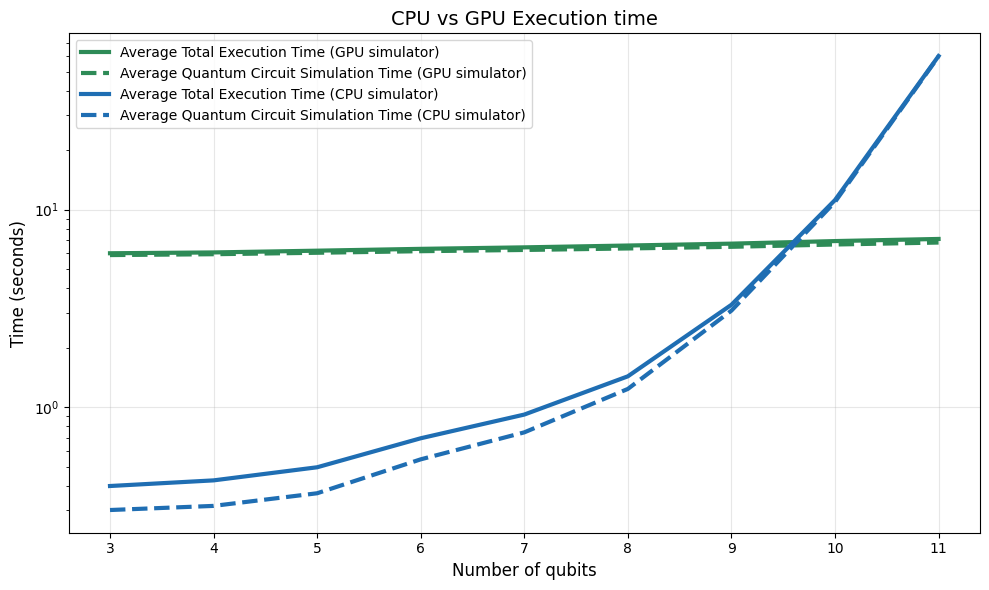

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

col1 = sns.color_palette('Blues', 24)[18]

plt.figure(figsize=(10, 6))

# Plot all_time_value with solid blue line
plt.plot(cudaq_avg_time['size'], cudaq_avg_time['avg_all_time'], label='Average Total Execution Time (GPU simulator)', color='seagreen', linewidth=3)

# Plot q_time_value with dashed green line
plt.plot(cudaq_avg_time['size'], cudaq_avg_time['avg_q_time'], label='Average Quantum Circuit Simulation Time (GPU simulator)', color='seagreen', linestyle='--', linewidth=3)


plt.plot(qiskit_avg_time['size'], qiskit_avg_time['avg_all_time'], label='Average Total Execution Time (CPU simulator)', color=col1, linewidth=3)

# Plot q_time_value with dashed green line
plt.plot(qiskit_avg_time['size'], qiskit_avg_time['avg_q_time'], label='Average Quantum Circuit Simulation Time (CPU simulator)', color=col1, linestyle='--', linewidth=3)


# Add labels and title
plt.xlabel('Number of qubits', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('CPU vs GPU Execution time', fontsize=14)

# Add grid and legend
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.grid(True, alpha=0.3)
plt.legend()

# Show plot
plt.tight_layout()

plt.savefig('cudaq_vs_qiskit_time.svg')


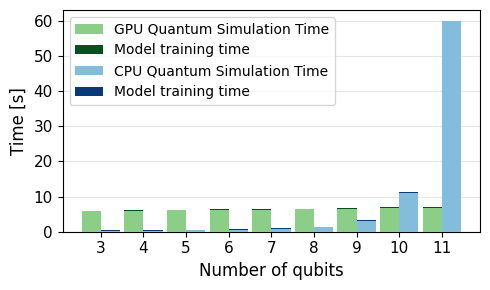

In [10]:
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

col1 = sns.color_palette('Blues', 24)[10]
col2 = sns.color_palette('Blues', 24)[23]
col3 = sns.color_palette('Greens', 24)[10]
col4 = sns.color_palette('Greens', 24)[23]

# Example data (replace with your actual data)
sizes = cudaq_avg_time['size']

# GPU data
gpu_q_time = np.array(cudaq_avg_time['avg_q_time'])
gpu_total_diff = np.array(cudaq_avg_time['avg_all_time']) - gpu_q_time

# CPU data
cpu_q_time = np.array(qiskit_avg_time['avg_q_time'])
cpu_total_diff = np.array(qiskit_avg_time['avg_all_time']) - cpu_q_time

x_indices = np.arange(len(sizes))
width = 0.45

fig, ax = plt.subplots(figsize=(5, 3))

# GPU bars
ax.bar(x_indices - width/2, gpu_q_time, width, label='GPU Quantum Simulation Time', color=col3, alpha=1, zorder=10)
ax.bar(x_indices - width/2, gpu_total_diff, width, bottom=gpu_q_time, label='Model training time', color=col4, alpha=1, zorder=10)

# CPU bars
ax.bar(x_indices + width/2, cpu_q_time, width, label='CPU Quantum Simulation Time', color=col1, alpha=1, zorder=10)
ax.bar(x_indices + width/2, cpu_total_diff, width, bottom=cpu_q_time, label='Model training time', color=col2, alpha=1, zorder=10)

# Labels and title
ax.set_xlabel('Number of qubits', fontsize=12)
ax.set_ylabel('Time [s]', fontsize=12)
# ax.set_title('CPU vs GPU Execution Time (Stacked Bar Chart)', fontsize=14)
ax.set_xticks(x_indices)
ax.set_xticklabels(sizes)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Logarithmic scale for y-axis
# ax.set_yscale('log')

# Legend and grid
ax.legend()
# ax.grid(True, alpha=0.3, zorder=1)
ax.grid(True, axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig('stacked_bar_cudaq_vs_qiskit_time.svg')
plt.show()


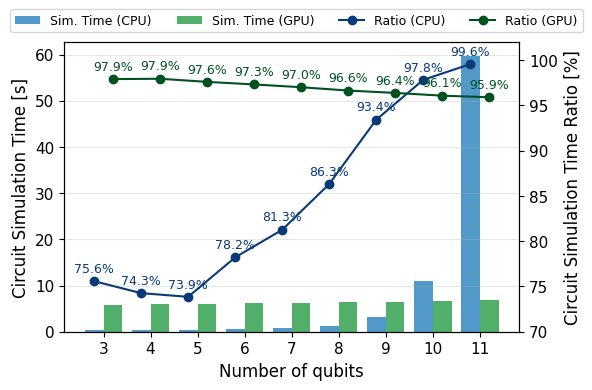

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Colors
col_cpu = sns.color_palette('Blues', 24)[15]
col_gpu = sns.color_palette('Greens', 24)[15]
line_cpu_col = sns.color_palette('Blues', 24)[23]
line_gpu_col = sns.color_palette('Greens', 24)[23]

# Data
sizes = cudaq_avg_time['size']
x_indices = np.arange(len(sizes))

# GPU and CPU quantum simulation times
gpu_q_time = np.array(cudaq_avg_time['avg_q_time'])
cpu_q_time = np.array(qiskit_avg_time['avg_q_time'])

# Total times
gpu_total_time = np.array(cudaq_avg_time['avg_all_time'])
cpu_total_time = np.array(qiskit_avg_time['avg_all_time'])

# Ratios
cpu_ratio = cpu_q_time / cpu_total_time * 100
gpu_ratio = gpu_q_time / gpu_total_time * 100

width = 0.4

fig, ax1 = plt.subplots(figsize=(6, 4))

# CPU bars
cpu_bar = ax1.bar(x_indices - width/2, cpu_q_time, width, color=col_cpu, alpha=0.9, label='CPU Sim. Time')

# GPU bars
gpu_bar = ax1.bar(x_indices + width/2, gpu_q_time, width, color=col_gpu, alpha=0.9, label='GPU Sim. Time')

# Axis labels
ax1.set_xlabel('Number of qubits', fontsize=12)
ax1.set_ylabel('Circuit Simulation Time [s]', fontsize=12)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(sizes, fontsize=11)
ax1.tick_params(axis='y', labelsize=11)

# Secondary axis for ratios
ax2 = ax1.twinx()
cpu_line, = ax2.plot(x_indices - width/2, cpu_ratio, marker='o', color=line_cpu_col, label='CPU Sim. Ratio')
gpu_line, = ax2.plot(x_indices + width/2, gpu_ratio, marker='o', color=line_gpu_col, label='GPU Sim. Ratio')
ax2.set_ylabel('Circuit Simulation Time Ratio [%]', fontsize=12)
ax2.tick_params(axis='y', labelsize=11)
ax2.set_ylim(70, 102) 

# Annotate values
for i, (x, y) in enumerate(zip(x_indices - width/2, cpu_ratio)):
    ax2.text(x, y + 1, f'{y:.1f}%', ha='center', color=line_cpu_col, fontsize=9)
for i, (x, y) in enumerate(zip(x_indices + width/2, gpu_ratio)):
    ax2.text(x, y + 1, f'{y:.1f}%', ha='center', color=line_gpu_col, fontsize=9)

# Legend
bars = [cpu_bar, gpu_bar]
lines = [cpu_line, gpu_line]
labels = ['CPU', 'GPU']
fig.legend(bars + lines, ['Sim. Time (CPU)', 'Sim. Time (GPU)', 'Ratio (CPU)', 'Ratio (GPU)'], loc='upper center', bbox_to_anchor=(0.5, 0.98), fontsize=9, ncol=4)

# Grid
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('quantum_simulation_time_ratio.svg')
plt.show()
